In [1]:
import pandas as pd
import numpy as np

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

# Clustering
from sklearn.cluster import KMeans

# Visualization
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("BreadBasket.csv")

df.head()

,Date,Time,Transaction,Item
0,2016-10-30,09:58:11,1,Bread
1,2016-10-30,10:05:34,2,Scandinavian
2,2016-10-30,10:05:34,2,Scandinavian
3,2016-10-30,10:07:57,3,Hot chocolate
4,2016-10-30,10:07:57,3,Jam


In [3]:
# Remove missing or unwanted rows
df = df.dropna()

# Remove "NONE" items if present
df = df[df['Item'] != 'NONE']

df.shape

(20507, 4)

In [4]:
transactions = df.groupby('Transaction')['Item'].apply(lambda x: ' '.join(x))
transactions = transactions.reset_index()

transactions.head()

,Transaction,Item
0,1,Bread
1,2,Scandinavian Scandinavian
2,3,Hot chocolate Jam Cookies
3,4,Muffin
4,5,Coffee Pastry Bread


In [5]:
nltk.download('punkt')
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def preprocess(text):
    tokens = word_tokenize(text.lower())
    tokens = [word for word in tokens if word.isalpha()]
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

transactions['Clean_Text'] = transactions['Item'].apply(preprocess)

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [6]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(transactions['Clean_Text'])

print(X.shape)

(9465, 136)


In [7]:
k = 5  # number of clusters
kmeans = KMeans(n_clusters=k, random_state=42)

kmeans.fit(X)

transactions['Cluster'] = kmeans.labels_

In [8]:
transactions[['Transaction', 'Cluster']].head()

,Transaction,Cluster
0,1,2
1,2,0
2,3,3
3,4,0
4,5,0


In [9]:
terms = vectorizer.get_feature_names_out()

for i in range(k):
    print(f"\nCluster {i}:")
    center = kmeans.cluster_centers_[i]
    top_words = [terms[ind] for ind in center.argsort()[-10:]]
    print(top_words)


Cluster 0:
['muffin', 'scandinavian', 'cookies', 'bread', 'farm', 'house', 'medialuna', 'sandwich', 'pastry', 'coffee']

Cluster 1:
['medialuna', 'toast', 'scone', 'cookies', 'pastry', 'soup', 'sandwich', 'bread', 'coffee', 'tea']

Cluster 2:
['alfajores', 'scone', 'brownie', 'sandwich', 'scandinavian', 'cookies', 'medialuna', 'pastry', 'coffee', 'bread']

Cluster 3:
['brownie', 'medialuna', 'pastry', 'tea', 'cookies', 'bread', 'cake', 'coffee', 'chocolate', 'hot']

Cluster 4:
['brownie', 'pastry', 'soup', 'muffin', 'juice', 'cookies', 'bread', 'tea', 'coffee', 'cake']


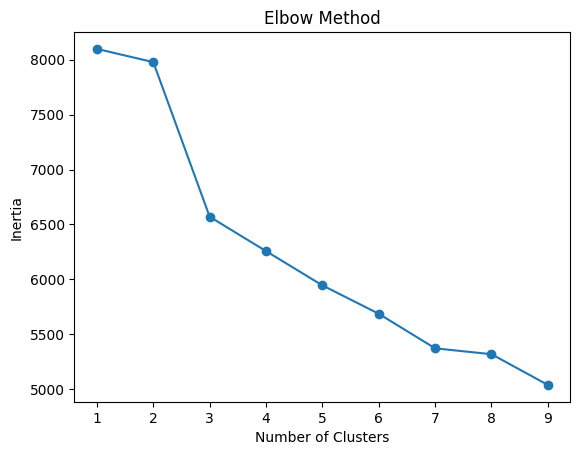

In [10]:
inertia = []

for i in range(1, 10):
    km = KMeans(n_clusters=i, random_state=42)
    km.fit(X)
    inertia.append(km.inertia_)

plt.plot(range(1, 10), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()